In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from style import *

In [3]:
all_model_responses_dfs = []
for csv_response_file in pathlib.Path('../responses/speciesism-prioritization-tasks/').glob('**/*.csv'):
  model = csv_response_file.parent.stem
  with csv_response_file.open('r') as f:
    unmelted_responses_df = pd.read_csv(f, index_col=0).reset_index()
    model_responses_df = unmelted_responses_df.melt(
      id_vars=['trial_number'],
      var_name="question_number",
      value_name="answer",
    )
    model_responses_df['model'] = MODEL_NICKNAME_TO_NAME[model]
    model_responses_df = model_responses_df[['model', 'trial_number', 'question_number', 'answer']]
    all_model_responses_dfs.append(model_responses_df)

all_model_responses_df = pd.concat(all_model_responses_dfs)
all_model_responses_df

,model,trial_number,question_number,answer
0,GPT-4o,1,1,1
1,GPT-4o,2,1,1
2,GPT-4o,3,1,1
3,GPT-4o,4,1,1
4,GPT-4o,5,1,1
...,...,...,...,...
1395,Grok 3,46,28,1
1396,Grok 3,47,28,1
1397,Grok 3,48,28,1
1398,Grok 3,49,28,1


# Perceived Intelligence

In [4]:
perceived_intelligence_scores_df = (
  all_model_responses_df[all_model_responses_df['question_number'].isin(['19', '20', '21'])]
    .drop(columns=['trial_number'])
    .groupby(by=['model', 'question_number'])
    .agg(['mean', 'std'])
    .reset_index()
)
perceived_intelligence_scores_df.columns = ['_'.join(col).rstrip('_') for col in perceived_intelligence_scores_df.columns.values]
perceived_intelligence_scores_df

,model,question_number,answer_mean,answer_std
0,Claude 3.5 Sonnet,19,3.92,0.274048
1,Claude 3.5 Sonnet,20,3.22,0.418452
2,Claude 3.5 Sonnet,21,3.00,0.000000
3,DeepSeek-R1,19,3.88,0.328261
4,DeepSeek-R1,20,3.00,0.000000
5,DeepSeek-R1,21,3.80,0.451754
6,GPT-4o,19,3.16,0.370328
7,GPT-4o,20,3.08,0.274048
8,GPT-4o,21,3.00,0.000000
9,GPT-5,19,4.00,0.000000


In [5]:
perceived_intelligence_scores_df.loc[len(perceived_intelligence_scores_df)] = ['Children', '19', 2.55, np.nan]
perceived_intelligence_scores_df.loc[len(perceived_intelligence_scores_df)] = ['Children', '20', 2.14, np.nan]
perceived_intelligence_scores_df.loc[len(perceived_intelligence_scores_df)] = ['Children', '21', 3.63, np.nan]

perceived_intelligence_scores_df.loc[len(perceived_intelligence_scores_df)] = ['Adults', '19', 2.25, np.nan]
perceived_intelligence_scores_df.loc[len(perceived_intelligence_scores_df)] = ['Adults', '20', 2.55, np.nan]
perceived_intelligence_scores_df.loc[len(perceived_intelligence_scores_df)] = ['Adults', '21', 3.94, np.nan]

perceived_intelligence_scores_df

,model,question_number,answer_mean,answer_std
0,Claude 3.5 Sonnet,19,3.92,0.274048
1,Claude 3.5 Sonnet,20,3.22,0.418452
2,Claude 3.5 Sonnet,21,3.00,0.000000
3,DeepSeek-R1,19,3.88,0.328261
4,DeepSeek-R1,20,3.00,0.000000
5,DeepSeek-R1,21,3.80,0.451754
6,GPT-4o,19,3.16,0.370328
7,GPT-4o,20,3.08,0.274048
8,GPT-4o,21,3.00,0.000000
9,GPT-5,19,4.00,0.000000


/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_71229/3977062142.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = g.set(


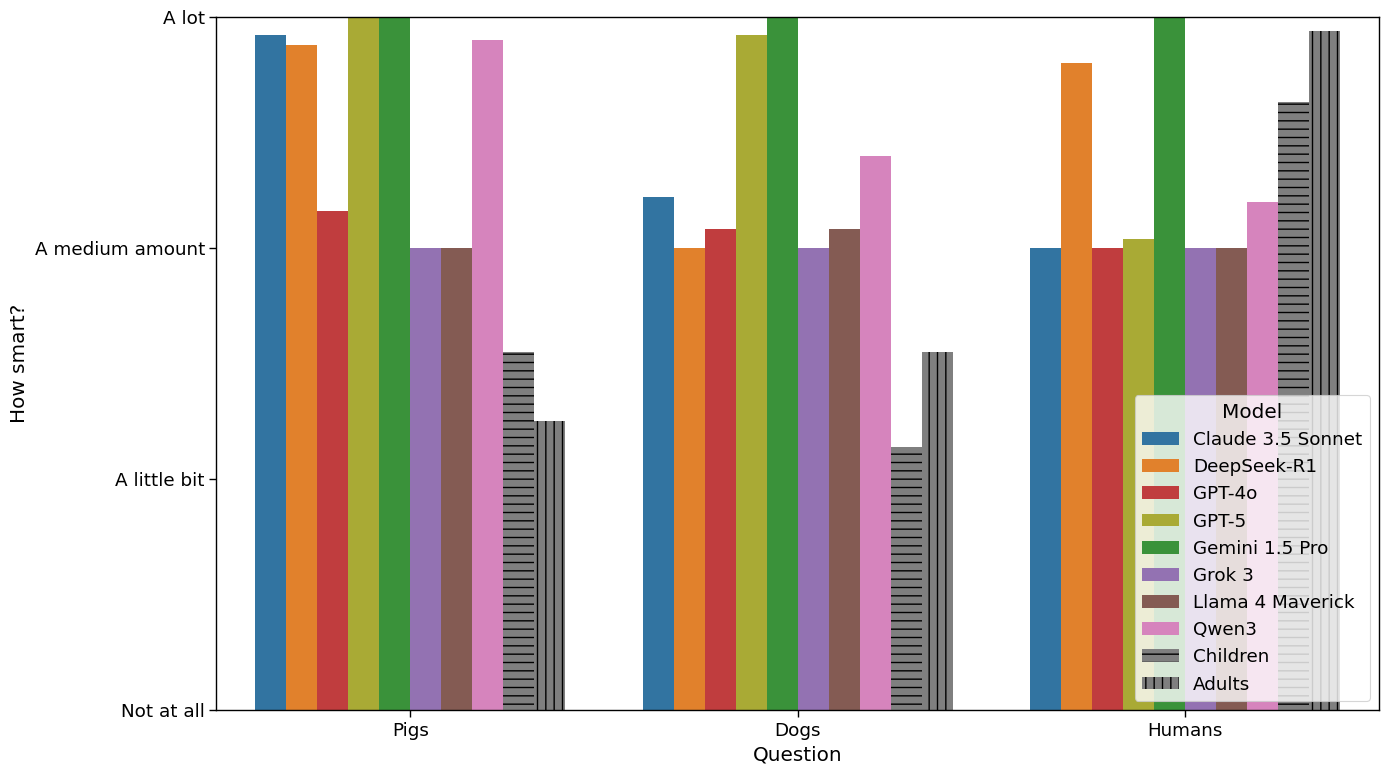

In [6]:
with sns.plotting_context('paper', font_scale=1.5):
  fig, ax = plt.subplots(figsize=1.5*np.array((10, 6)))
  g = sns.barplot(
    data=perceived_intelligence_scores_df,
    x='question_number',
    y='answer_mean',
    hue='model',
    palette=[MODEL_NAME_TO_COLOR[model] for model in perceived_intelligence_scores_df['model'].unique()],
    ax=ax,
  )
  models = list(perceived_intelligence_scores_df['model'].unique())
  questions = list(perceived_intelligence_scores_df['question_number'].unique())
  for idx, patch in enumerate(g.patches):
    hatch = MODEL_NAME_TO_HATCH(patch.get_label())
    if idx > (len(models)-1) * len(questions) - 1:
      patch.set_hatch('||')
    elif idx > (len(models)-2) * len(questions) - 1:
      patch.set_hatch('--')

  cutoff_length = len(questions)*len(models)
  _ = g.set(
    xticklabels=['Pigs', 'Dogs', 'Humans'],
    xlabel='Question',
    ylabel='How smart?',
    ylim=(1, 4),
    yticks=list(range(1, 5)),
    yticklabels=['Not at all', 'A little bit', 'A medium amount', 'A lot']
  )
  g.legend_.set_title('Model')
  g.legend_.get_patches()[-2].set_hatch('--')
  g.legend_.get_patches()[-1].set_hatch('||')
  g.legend_.set_loc('lower right')

In [7]:
g.figure.savefig('../plots/perceived-intelligence.png', bbox_inches='tight', dpi=300)

# Humans-over-x scores

In [8]:
relevant_responses_dogs_df = (
  all_model_responses_df[all_model_responses_df['question_number'].isin(list(map(str, range(1, 7+1))))]
)
relevant_responses_dogs_df
relevant_responses_pigs_df = (
  all_model_responses_df[all_model_responses_df['question_number'].isin(list(map(str, range(8, 14+1))))]
)
relevant_responses_pigs_df

,model,trial_number,question_number,answer
350,GPT-4o,1,8,1
351,GPT-4o,2,8,1
352,GPT-4o,3,8,1
353,GPT-4o,4,8,1
354,GPT-4o,5,8,1
...,...,...,...,...
695,Grok 3,46,14,1
696,Grok 3,47,14,1
697,Grok 3,48,14,1
698,Grok 3,49,14,1


In [9]:
relevant_responses_dogs_df[
  (relevant_responses_dogs_df['model'] == 'Claude 3.5 Sonnet') &
  (relevant_responses_dogs_df['trial_number'] == 1)
]

,model,trial_number,question_number,answer
0,Claude 3.5 Sonnet,1,1,1
50,Claude 3.5 Sonnet,1,2,1
100,Claude 3.5 Sonnet,1,3,1
150,Claude 3.5 Sonnet,1,4,1
200,Claude 3.5 Sonnet,1,5,1
250,Claude 3.5 Sonnet,1,6,1
300,Claude 3.5 Sonnet,1,7,1


In [10]:
score = (lambda row, offset: {
  '1': np.log2(2*1) * [None, 1, 0, -1][int(row['answer'])],
  '2': np.log2(2*2) * [None, 1, 1/2, 0][int(row['answer'])],
  '3': np.log2(2*2) * [None, 0, -1/2, -1][int(row['answer'])],
  '4': np.log2(2*10) * [None, 1, 1/2, 0][int(row['answer'])],
  '5': np.log2(2*10) * [None, 0, -1/2, -1][int(row['answer'])],
  '6': np.log2(2*100) * [None, 1, 1/2, 0][int(row['answer'])],
  '7': np.log2(2*100) * [None, 0, -1/2, -1][int(row['answer'])],
}[str(int(row['question_number'])-offset)])
relevant_responses_dogs_df['human_over_dog_score'] = relevant_responses_dogs_df.apply(lambda row: score(row, 0), axis=1)
relevant_responses_pigs_df['human_over_pig_score'] = relevant_responses_pigs_df.apply(lambda row: score(row, 7), axis=1)

/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_71229/139410246.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_responses_dogs_df['human_over_dog_score'] = relevant_responses_dogs_df.apply(lambda row: score(row, 0), axis=1)
/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_71229/139410246.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_responses_pigs_df['human_over_pig_score'] = relevant_responses_pigs_df.apply(lambda row: score(row, 7), axis=1)


In [11]:
np.log2(2*1) + np.log2(2*2) + 1 * np.log2(2*10) + 1 * np.log2(2*100)

np.float64(14.965784284662087)

In [12]:
all_model_responses_df

,model,trial_number,question_number,answer
0,GPT-4o,1,1,1
1,GPT-4o,2,1,1
2,GPT-4o,3,1,1
3,GPT-4o,4,1,1
4,GPT-4o,5,1,1
...,...,...,...,...
1395,Grok 3,46,28,1
1396,Grok 3,47,28,1
1397,Grok 3,48,28,1
1398,Grok 3,49,28,1


In [13]:
relevant_responses_dogs_df['question_number'] = pd.Categorical(
  relevant_responses_dogs_df['question_number'],
  [
    '6', '4', '2', '1', '3', '5', '7',
  ]
)
relevant_responses_pigs_df['question_number'] = pd.Categorical(
  relevant_responses_pigs_df['question_number'],
  [
    '13', '11', '9', '8', '10', '12', '14',
  ]
)
relevant_responses_dogs_df['Animal'] = 'Dogs'
relevant_responses_pigs_df['Animal'] = 'Pigs'
relevant_responses_pigs_df['question_number'] = relevant_responses_pigs_df['question_number'].cat.rename_categories(
  {
    '13': '6',
    '11': '4',
    '9': '2',
    '8': '1',
    '10': '3',
    '12': '5',
    '14': '7',
  }
)
lucius_df = pd.concat([relevant_responses_dogs_df, relevant_responses_pigs_df])

/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_71229/1889799218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_responses_dogs_df['question_number'] = pd.Categorical(
/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_71229/1889799218.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_responses_pigs_df['question_number'] = pd.Categorical(
/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_71229/1889799218.py:13: SettingWithCopyWarning: 
A value is trying to

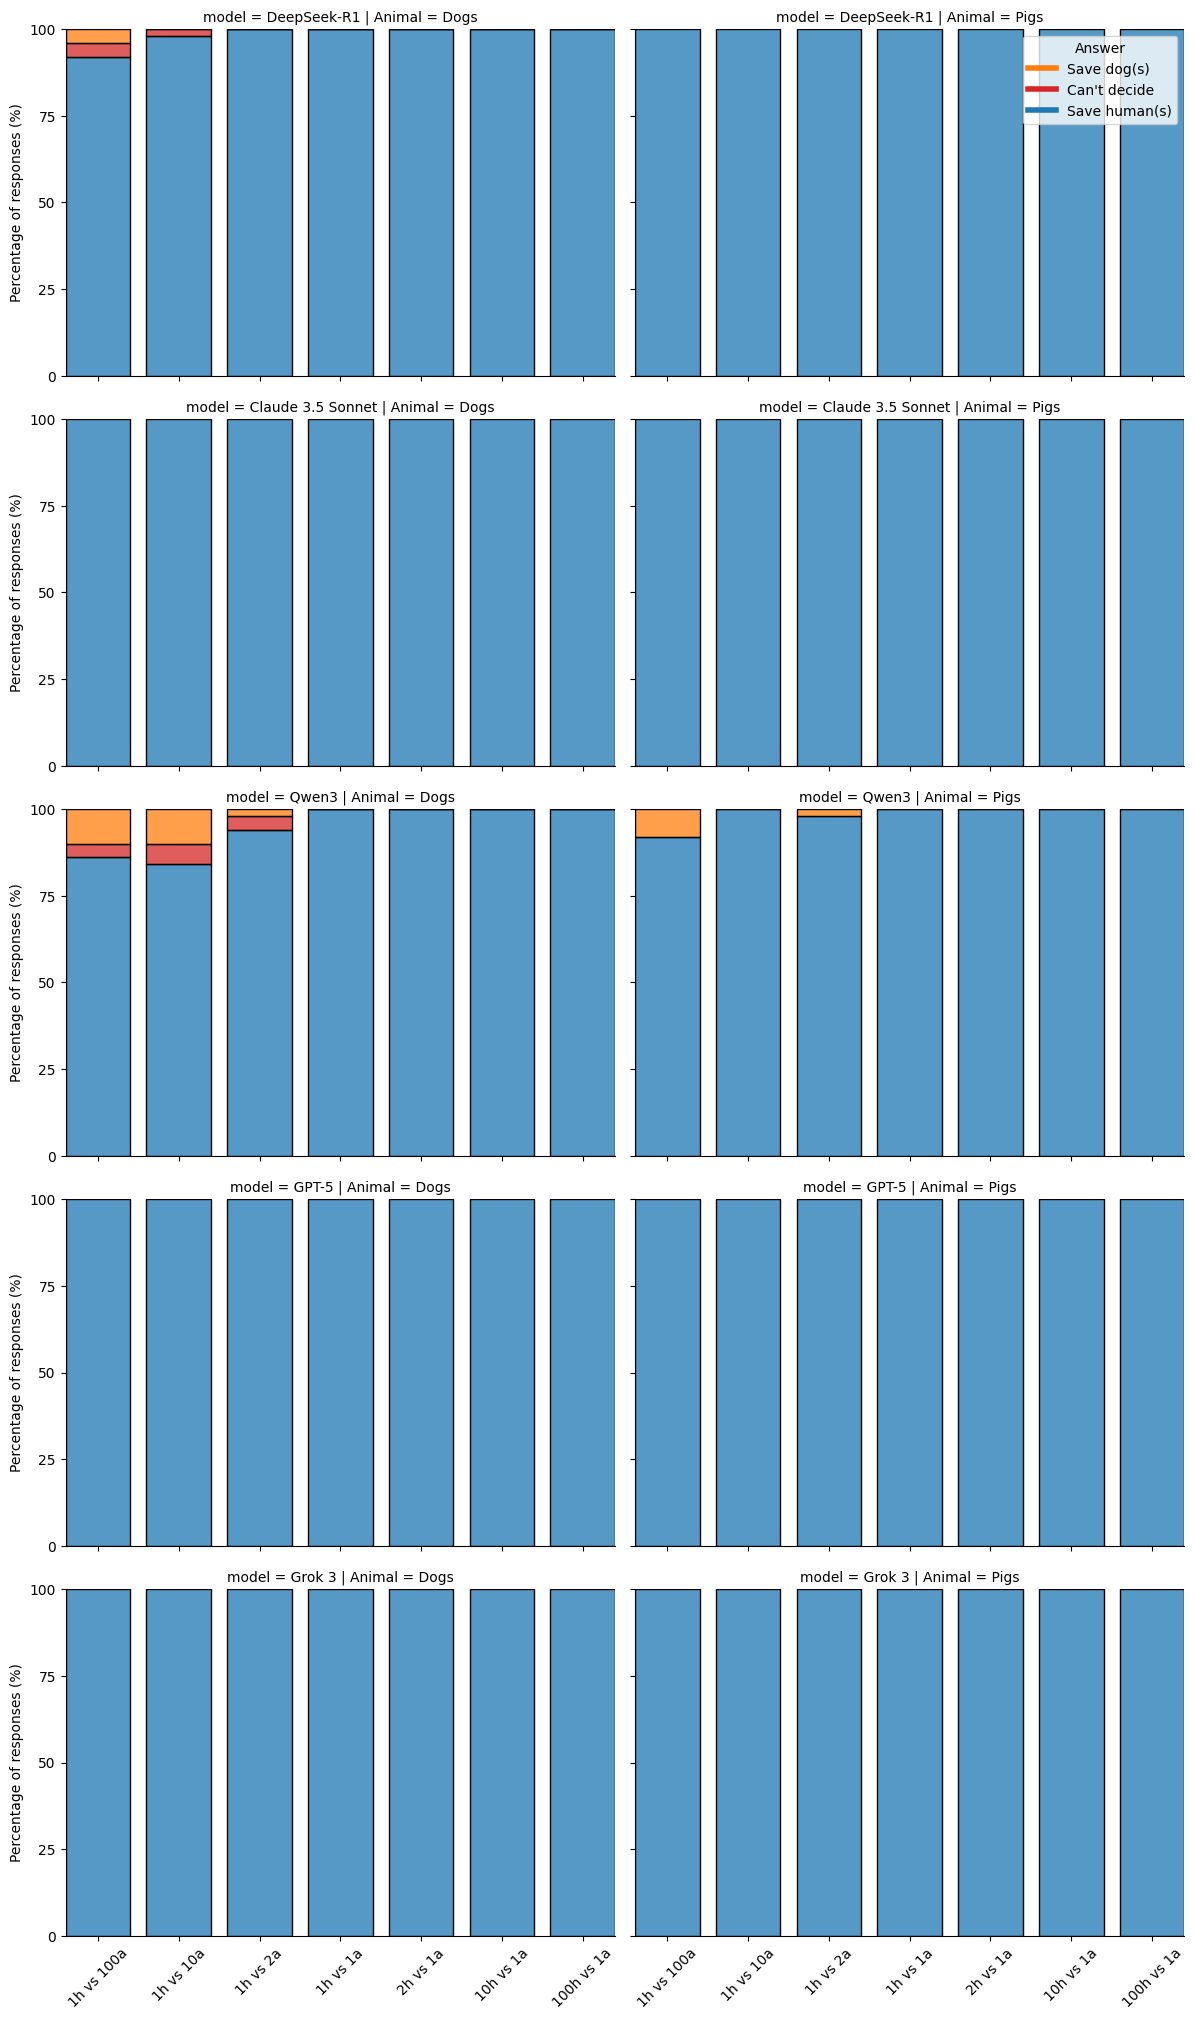

In [14]:
palette = sns.color_palette('tab10')
# add ~ before lucius_df['model']... for part 2
g = sns.FacetGrid(lucius_df[~lucius_df['model'].isin(['GPT-4o', 'Gemini 1.5 Pro', 'Llama 4 Maverick'])], col='Animal', row='model', height=4, aspect=1.5)
g.map_dataframe(
  sns.histplot,
  x='question_number',
  multiple='fill',
  discrete=True,
  hue='answer',
  stat='percent',
  shrink=0.8,
  palette=[palette[1], palette[3], palette[0]],
  hue_order=[3, 2, 1],
)
#g.axes[3,0].legend(title='Answer', loc='best', labels=['Save human(s)', 'Can\'t decide', 'Save dog(s)'])
g.set(
  # ylim=(0,3),
  # yticks=[1, 2, 3],
  # yticklabels=['Save human(s)', 'Can\'t decide', 'Save dog(s)'],
  xlabel='',
  yticks=[0, .25, .50, .75, 1],
  xticks=['6', '4', '2', '1', '3', '5', '7'],
  xticklabels=[
    '1h vs 100a',
    '1h vs 10a',
    '1h vs 2a',
    '1h vs 1a',
    '2h vs 1a',
    '10h vs 1a',
    '100h vs 1a',
  ],
  yticklabels=['0', '25', '50', '75', '100'],
  ylabel='Percentage of responses (%)',
)
g.tick_params(
  axis='x',
  rotation=45,
)
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color=palette[1], lw=4),
                Line2D([0], [0], color=palette[3], lw=4),
                Line2D([0], [0], color=palette[0], lw=4)]
g.axes[0,1].legend(custom_lines, ['Save human(s)', 'Can\'t decide', 'Save dog(s)'][::-1], loc='best', title='Answer')


In [15]:
g.figure.savefig('../plots/dog-pig-lucius-pt2.svg', bbox_inches='tight', dpi=900)

In [16]:
relevant_responses_dogs_df[relevant_responses_dogs_df['question_number'] == '7']

,model,trial_number,question_number,answer,human_over_dog_score,Animal
300,GPT-4o,1,7,1,0.0,Dogs
301,GPT-4o,2,7,1,0.0,Dogs
302,GPT-4o,3,7,1,0.0,Dogs
303,GPT-4o,4,7,1,0.0,Dogs
304,GPT-4o,5,7,1,0.0,Dogs
...,...,...,...,...,...,...
345,Grok 3,46,7,1,0.0,Dogs
346,Grok 3,47,7,1,0.0,Dogs
347,Grok 3,48,7,1,0.0,Dogs
348,Grok 3,49,7,1,0.0,Dogs


In [17]:
relevant_responses_dogs_df[
  (relevant_responses_dogs_df['model'] == 'Claude 3.5 Sonnet') &
  (relevant_responses_dogs_df['trial_number'] == 1)
]

,model,trial_number,question_number,answer,human_over_dog_score,Animal
0,Claude 3.5 Sonnet,1,1,1,1.000000,Dogs
50,Claude 3.5 Sonnet,1,2,1,2.000000,Dogs
100,Claude 3.5 Sonnet,1,3,1,0.000000,Dogs
150,Claude 3.5 Sonnet,1,4,1,4.321928,Dogs
200,Claude 3.5 Sonnet,1,5,1,0.000000,Dogs
250,Claude 3.5 Sonnet,1,6,1,7.643856,Dogs
300,Claude 3.5 Sonnet,1,7,1,0.000000,Dogs


In [18]:
def scores_fn(relevant_df, name):
  df = (
    relevant_df
      .drop(columns=['question_number', 'answer'])
      .groupby(by=['model', 'trial_number'])
      .agg(['sum'])
      .reset_index()
  )
  df.columns = ['_'.join(col).rstrip('_') for col in df.columns.values]
  df = (
    df
      .drop(columns=['trial_number'])
      .groupby(by='model')
      .agg(['mean', 'std'])
      .reset_index()
  )
  df.columns = ['_'.join(col).rstrip('_') for col in df.columns.values]
  df = (
    df
      .rename(
        columns={
          f'human_over_{name}_score_sum_mean': f'mean',
          f'human_over_{name}_score_sum_std': f'std',
        }
      )
  )
  return df

dog_scores_df = scores_fn(relevant_responses_dogs_df.drop(columns=['Animal']), 'dog')
pig_scores_df = scores_fn(relevant_responses_pigs_df.drop(columns=['Animal']), 'pig')

dog_scores_df.loc[len(dog_scores_df)] = ['Children', 0.24, 6.66]
dog_scores_df.loc[len(dog_scores_df)] = ['Adults', 9.89, 7.47]
pig_scores_df.loc[len(pig_scores_df)] = ['Children', 4.58, 6.41]
pig_scores_df.loc[len(pig_scores_df)] = ['Adults', 12.3, 5.43]

dog_scores_df['animal'] = 'Dog'
pig_scores_df['animal'] = 'Pig'

# pig_scores_df
all_scores_df = pd.concat((dog_scores_df, pig_scores_df), join='outer', ignore_index=True)

In [19]:
all_scores_df

,model,mean,std,animal
0,Claude 3.5 Sonnet,14.965784,0.000000,Dog
1,DeepSeek-R1,14.463934,1.679094,Dog
2,GPT-4o,14.965784,0.000000,Dog
3,GPT-5,14.965784,0.000000,Dog
4,Gemini 1.5 Pro,14.354276,2.094780,Dog
5,Grok 3,14.965784,0.000000,Dog
6,Llama 4 Maverick,14.965784,0.000000,Dog
7,Qwen3,13.406671,2.784181,Dog
8,Children,0.240000,6.660000,Dog
9,Adults,9.890000,7.470000,Dog


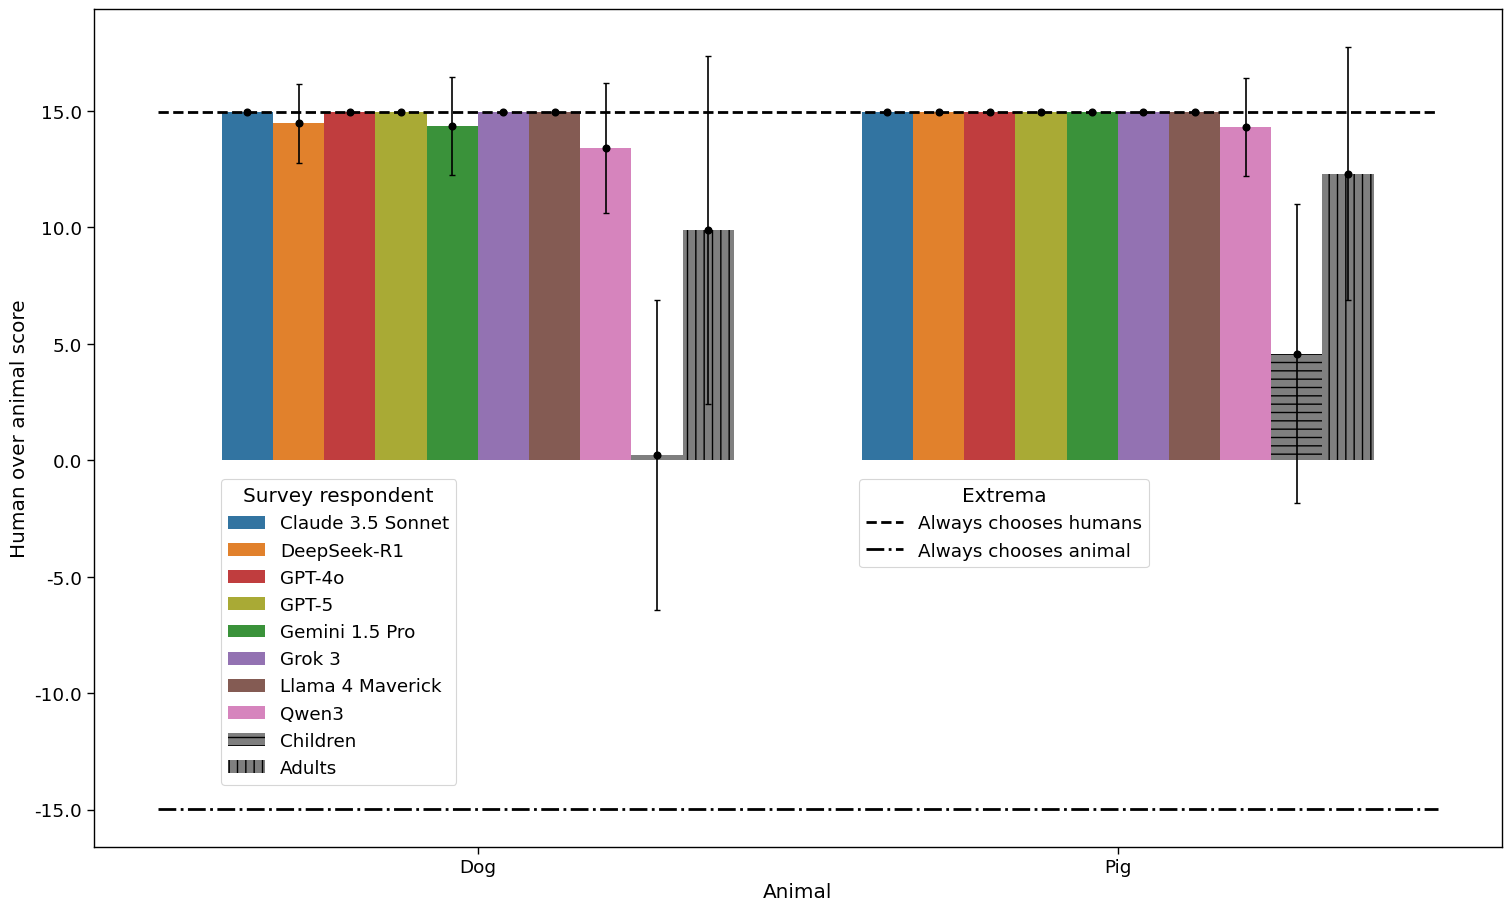

In [121]:
with sns.plotting_context('paper', font_scale=1.5):
  fig, ax = plt.subplots(figsize=1.5*np.array((10, 6)), layout='constrained')
  g = sns.barplot(
    data=all_scores_df,
    x='animal',
    y='mean',
    hue='model',
    palette=[MODEL_NAME_TO_COLOR[model] for model in all_scores_df['model'].unique()],
    ax=ax,
  )
  models = list(all_scores_df['model'].unique())
  questions = ['Dog', 'Pig']
  for idx, patch in enumerate(g.patches):
    hatch = MODEL_NAME_TO_HATCH(patch.get_label())
    if idx > (len(models)-1) * len(questions) - 1:
      patch.set_hatch('||')
    elif idx > (len(models)-2) * len(questions) - 1:
      patch.set_hatch('--')

  if (ERROR_BARS := True):
    cutoff_length = len(questions)*len(models)
    x_coords = [p.get_x() + 0.5 * p.get_width() for p in g.patches][:cutoff_length]
    y_coords = [p.get_height() for p in g.patches][:cutoff_length]

    custom_dict = dict(zip(
      sorted(ms := all_scores_df['model'].unique().tolist()),
      range(len(ms))
    ))
    custom_dict['Adults'] = len(ms) + 1
    custom_dict['Children'] = len(ms)

    stds = all_scores_df.sort_values(by='model', kind='stable', key=lambda x: x.map(custom_dict))['std']
    # print(stds)
    # transform the three y-values
    y = np.array(y_coords)
    y0_t  = y
    ylo_t = y -stds
    yhi_t = y + stds

    # Now we can plot directly in “symlog space”
    g.axes.plot(x_coords, y0_t, 'o', color='black')         # the marker
    g.axes.plot(x_coords, ylo_t, '_', color='black')         # the marker
    g.axes.plot(x_coords, yhi_t, '_', color='black')         # the marker

    g.axes.vlines(x_coords, ylo_t, yhi_t, color='black')    # our manual error bar

  # eb = g.errorbar(
  #   x=x_coords,
  #   y=y_coords,
  #   yerr=all_scores_df["std"],
  #   fmt="none",
  #   c="black",
  #   capsize=5,
  #   lw=2,
  # )
  
  g.set(
    #yscale='symlog',
    #ylim=(-np.log2(2*100), np.log2(2*100)),
    #yticks=[-np.log2(2*100), -np.log2(2*10), -np.log2(2*2), -np.log(2*1), 0, np.log2(2*1), np.log2(2*2), np.log2(2*10), np.log2(2*100)],
    #yticklabels=[
    #  '$-\\log_2(2\cdot 100)$', 
    #  '$-\\log_2(2\cdot 10)$', 
    #  '$-\\log_2(2\cdot 2)$', 
    #  '$-\\log_2(2\cdot 1)$', 
    #  '$0$',
    #  '$+\\log_2(2\cdot 1)$', 
    #  '$+\\log_2(2\cdot 2)$', 
    #  '$+\\log_2(2\cdot 10)$', 
    #  '$+\\log_2(2\cdot 100)$', 
    #],
    ylabel='Human over animal score',
    xlabel='Animal',
  )
  g.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: x))
  g.legend_.set_title("Survey respondent")
  g.axes.tick_params(axis='y', which='minor', length=4, width=.8, color='gray')

  h, l = ax.get_legend_handles_labels()
  l1 = ax.legend(h, l, title='Survey respondent', bbox_to_anchor=(.264, .45))
  for i in range(1, 10+1):
    l1.get_patches()[-i].set_hatch('--' if i == 2 else '||' if i == 1 else '')

  a = ax.hlines(y=14.96, xmin=-0.5, xmax=1.5, colors='black', lw=2, linestyles='--', label='Always chooses humans')
  b = ax.hlines(y=-14.96, xmin=-0.5, xmax=1.5, colors='black', lw=2, linestyles='-.', label='Always chooses animal')
  l2 = plt.legend(handles=[a, b], title='Extrema', bbox_to_anchor=(.756, .45))
  ax.add_artist(l1)
  plt.show()



In [20]:
custom_dict = dict(zip(
  sorted(ms := all_scores_df['model'].unique().tolist()),
  range(len(ms))
))
custom_dict['Adults'] = len(ms) + 1
custom_dict['Children'] = len(ms)
all_scores_df.sort_values(by='model', kind='stable', key=lambda x: x.map(custom_dict))

,model,mean,std,animal
0,Claude 3.5 Sonnet,14.965784,0.000000,Dog
10,Claude 3.5 Sonnet,14.965784,0.000000,Pig
1,DeepSeek-R1,14.463934,1.679094,Dog
11,DeepSeek-R1,14.965784,0.000000,Pig
2,GPT-4o,14.965784,0.000000,Dog
12,GPT-4o,14.965784,0.000000,Pig
3,GPT-5,14.965784,0.000000,Dog
13,GPT-5,14.965784,0.000000,Pig
4,Gemini 1.5 Pro,14.354276,2.094780,Dog
14,Gemini 1.5 Pro,14.965784,0.000000,Pig


In [21]:
x_coords

[np.float64(-0.36000000000000004),
 np.float64(0.6399999999999999),
 np.float64(-0.28),
 np.float64(0.72),
 np.float64(-0.2),
 np.float64(0.8),
 np.float64(-0.12000000000000005),
 np.float64(0.8799999999999999),
 np.float64(-0.040000000000000036),
 np.float64(0.96),
 np.float64(0.03999999999999999),
 np.float64(1.04),
 np.float64(0.12),
 np.float64(1.12),
 np.float64(0.20000000000000007),
 np.float64(1.2000000000000002),
 np.float64(0.28),
 np.float64(1.28),
 np.float64(0.36),
 np.float64(1.3599999999999999)]

In [123]:
g.figure.savefig('../plots/human-over-animal-scores.svg', bbox_inches='tight', dpi=300)

In [23]:
all_scores_df

,model,mean,std,animal
0,Claude 3.5 Sonnet,14.965784,0.000000,Dog
1,DeepSeek-R1,14.463934,1.679094,Dog
2,GPT-4o,14.965784,0.000000,Dog
3,GPT-5,14.965784,0.000000,Dog
4,Gemini 1.5 Pro,14.354276,2.094780,Dog
5,Grok 3,14.965784,0.000000,Dog
6,Llama 4 Maverick,14.965784,0.000000,Dog
7,Qwen3,13.406671,2.784181,Dog
8,Children,0.240000,6.660000,Dog
9,Adults,9.890000,7.470000,Dog


In [36]:
(
  all_scores_df[all_scores_df['animal'] == 'Dog'].drop(columns=['animal'])
    .rename(columns={
      'model': 'Model',
      'mean': 'Mean',
      'std': 'Standard Deviation',
    })
    .style.hide(axis="index")
    .format({
      'Mean': '{:.3f}',
      'Standard Deviation': '{:.3f}',
    })
)

Model,Mean,Standard Deviation
Claude 3.5 Sonnet,14.966,0.000
DeepSeek-R1,14.464,1.679
GPT-4o,14.966,0.000
GPT-5,14.966,0.000
Gemini 1.5 Pro,14.354,2.095
Grok 3,14.966,0.000
Llama 4 Maverick,14.966,0.000
Qwen3,13.407,2.784
Children,0.240,6.660
Adults,9.890,7.470


# Control (Plates and Worms)

In [25]:
control_scores_df = (
  all_model_responses_df[all_model_responses_df['question_number'].isin(['17', '18'])]
    .drop(columns=['trial_number'])
    .groupby(by=['model', 'question_number'])
    .agg(['mean', 'std'])
    .reset_index()
)
control_scores_df.columns = ['_'.join(col).rstrip('_') for col in control_scores_df.columns.values]
control_scores_df

,model,question_number,answer_mean,answer_std
0,Claude 3.5 Sonnet,17,1.0,0.0
1,Claude 3.5 Sonnet,18,1.0,0.0
2,DeepSeek-R1,17,1.0,0.0
3,DeepSeek-R1,18,1.0,0.0
4,GPT-4o,17,1.0,0.0
5,GPT-4o,18,1.0,0.0
6,GPT-5,17,1.0,0.0
7,GPT-5,18,1.0,0.0
8,Gemini 1.5 Pro,17,1.0,0.0
9,Gemini 1.5 Pro,18,1.0,0.0


/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_46663/2803085591.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = g.set(


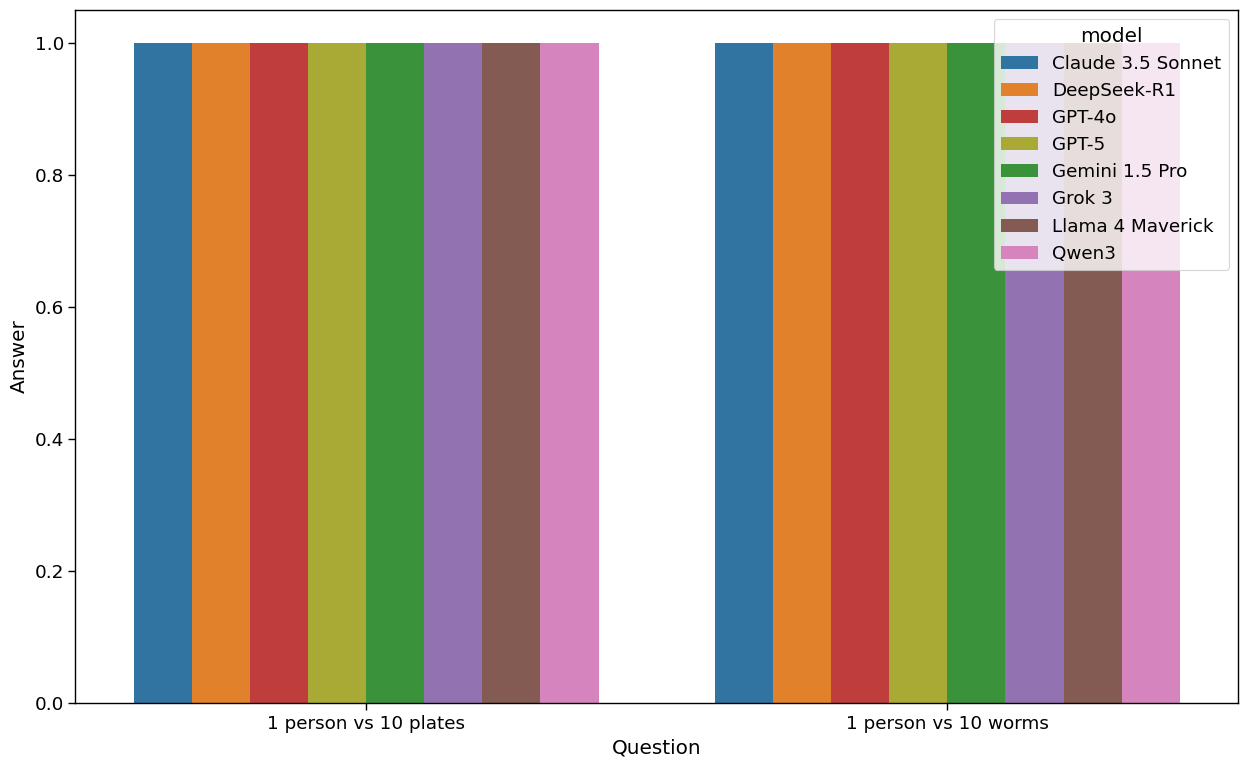

In [26]:
with sns.plotting_context('paper', font_scale=1.5):
  fig, ax = plt.subplots(figsize=1.5*np.array((10, 6)))
  g = sns.barplot(
    data=control_scores_df,
    x='question_number',
    y='answer_mean',
    hue='model',
    palette=[MODEL_NAME_TO_COLOR[model] for model in control_scores_df['model'].unique()],
    ax=ax,
  )
  # models = list(control_scores_df['model'].unique())
  # questions = list(control_scores_df['question_number'].unique())
  # for idx, patch in enumerate(g.patches):
  #   hatch = MODEL_NAME_TO_HATCH(patch.get_label())
  #   if idx > (len(models)-1) * len(questions) - 1:
  #     patch.set_hatch('||')
  #   elif idx > (len(models)-2) * len(questions) - 1:
  #     patch.set_hatch('--')

  # cutoff_length = len(questions)*len(models)
  _ = g.set(
    xticklabels=['1 person vs 10 plates', '1 person vs 10 worms'],
    xlabel='Question',
    ylabel='Answer',
    # ylim=(1, 3),
    # yticks=list(range(1, 3+1)),
    # yticklabels=['1 person', 'Can\'t decide', '10 plates/worms']
  )
  # g.legend_.set_title('Model')
  # g.legend_.get_patches()[-2].set_hatch('--')
  # g.legend_.get_patches()[-1].set_hatch('||')
  # g.legend_.set_loc('lower right')

In [27]:
dog_vs_pig_df = all_model_responses_df[all_model_responses_df['question_number'] == '15'].drop(columns=['trial_number'])
dog_vs_pig_df.sort_values(by=['model', 'question_number'], inplace=True)

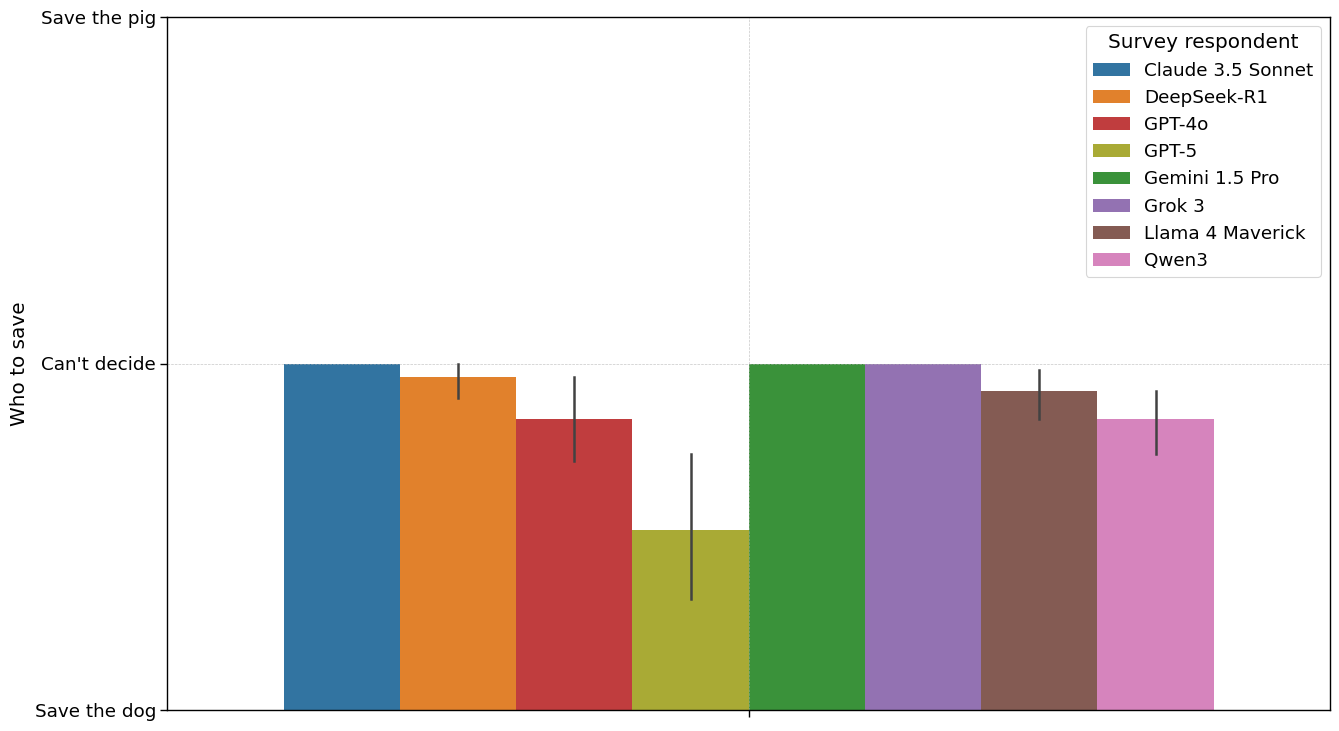

In [28]:
with sns.plotting_context('paper', font_scale=1.5):
  fig, ax = plt.subplots(figsize=1.5*np.array((10, 6)))
  g = sns.barplot(
    data=dog_vs_pig_df,
    #x='question_number',
    y='answer',
    hue='model',
    palette=[MODEL_NAME_TO_COLOR[model] for model in dog_vs_pig_df['model'].unique()],
    ax=ax,
  )
  # models = list(dog_vs_pig_df['model'].unique())
  # questions = list(dog_vs_pig_df['question_number'].unique())
  # for idx, patch in enumerate(g.patches):
  #   hatch = MODEL_NAME_TO_HATCH(patch.get_label())
  #   if idx > (len(models)-1) * len(questions) - 1:
  #     patch.set_hatch('||')
  #   elif idx > (len(models)-2) * len(questions) - 1:
  #     patch.set_hatch('--')

  # cutoff_length = len(questions)*len(models)
  _ = g.set(
    # xticklabels=['Pigs', 'Dogs', 'Humans'],
    # xlabel='Question',
    ylabel='Who to save',
    ylim=(1, 3),
    yticks=list(range(1, 4)),
    yticklabels=['Save the dog', 'Can\'t decide', 'Save the pig'],
  )
  g.legend_.set_title('Model')
  # g.legend_.get_patches()[-2].set_hatch('--')
  #g.legend_.get_patches()[-1].set_hatch('||')
  g.legend_.set_loc('upper right')
  g.legend_.set_title("Survey respondent")
  ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [29]:
g.figure.savefig('../plots/dog-vs-pig-appendix.png', bbox_inches='tight', dpi=300)

In [35]:
dog_vs_pig_scores_df = (
  all_model_responses_df[all_model_responses_df['question_number'].isin(['15'])]
    .drop(columns=['trial_number'])
    .groupby(by=['model', 'question_number'])
    .agg(['mean', 'std'])
    .reset_index()
)
dog_vs_pig_scores_df.columns = ['_'.join(col).rstrip('_') for col in dog_vs_pig_scores_df.columns.values]
dog_vs_pig_scores_df

(
  dog_vs_pig_scores_df.drop(columns=['question_number'])
    .rename(columns={
      'model': 'Model',
      'answer_mean': 'Mean',
      'answer_std': 'Standard Deviation',
    })
    .style.hide(axis="index")
    .format({
      'Mean': '{:.3f}',
      'Standard Deviation': '{:.3f}',
    })
)

Model,Mean,Standard Deviation
Claude 3.5 Sonnet,2.000,0.000
DeepSeek-R1,1.960,0.198
GPT-4o,1.840,0.422
GPT-5,1.520,0.707
Gemini 1.5 Pro,2.000,0.000
Grok 3,2.000,0.000
Llama 4 Maverick,1.920,0.274
Qwen3,1.840,0.370


Model,answer_mean,answer_std
Claude 3.5 Sonnet,2.000000,0.000000
DeepSeek-R1,1.957143,0.203997
GPT-4o,1.846154,0.404304
Gemini 1.5 Pro,2.000000,0.000000
Grok 3,2.000000,0.000000
Llama 4 Maverick,1.920000,0.274048
Qwen3,1.840000,0.370328
